In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from data_filtering import InsuranceDataProcessor

In [3]:
idp = InsuranceDataProcessor('configs/filters')

df, _ = idp.handle_nans(pd.read_csv('~/MLOps/vehicle-insurance-data/motor_data11-14lats.csv'), True)

In [4]:
filtering_config = {'INSR_ZERO': {}, 'ELSE': {}}

# Боксплоты для фильтрации выбросов

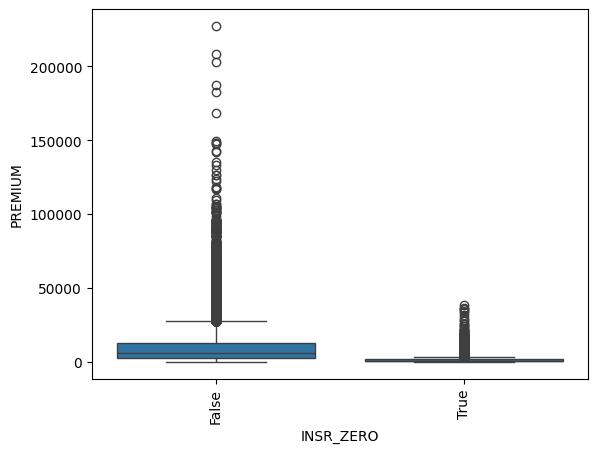

In [5]:
df['INSR_ZERO'] = (df['INSURED_VALUE'] == 0)

sns.boxplot(data=df, x='INSR_ZERO', y='PREMIUM')
plt.xticks(rotation = 90)
plt.show()

In [6]:
df = df[df['INSURED_VALUE'] == 0].reset_index(drop=True)  # заменить знак для анализа другой части

insr_key = 'INSR_ZERO' if df.iloc[0]['INSR_ZERO'] else 'ELSE'

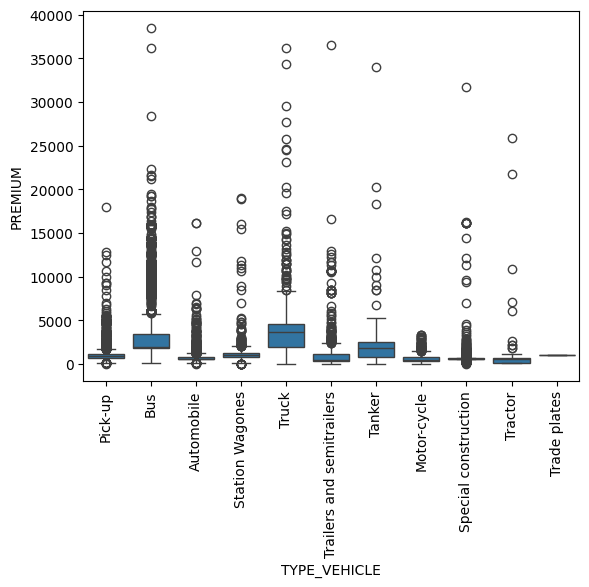

6211


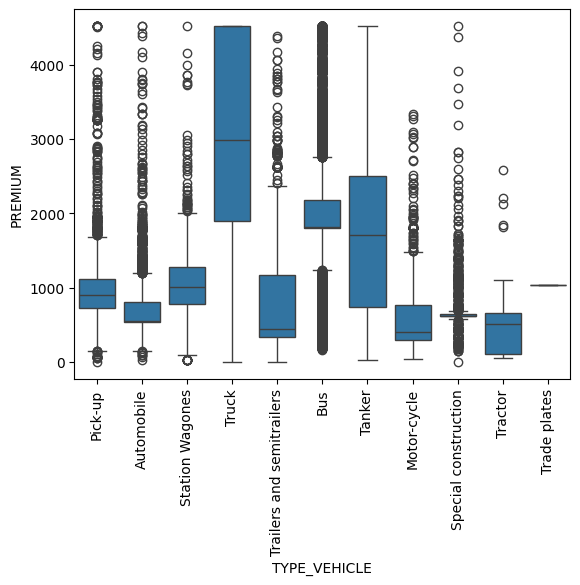

In [7]:
sns.boxplot(data=df, x='TYPE_VEHICLE', y='PREMIUM')
plt.xticks(rotation = 90)
plt.show()

prem_quantile = df['PREMIUM'].quantile(0.95)
filtering_config[insr_key]['PREMIUM'] = prem_quantile

print((df['PREMIUM'] >= prem_quantile).sum())

df = df[df['PREMIUM'] < prem_quantile].reset_index(drop=True)

sns.boxplot(data=df, x='TYPE_VEHICLE', y='PREMIUM')
plt.xticks(rotation = 90)
plt.show()

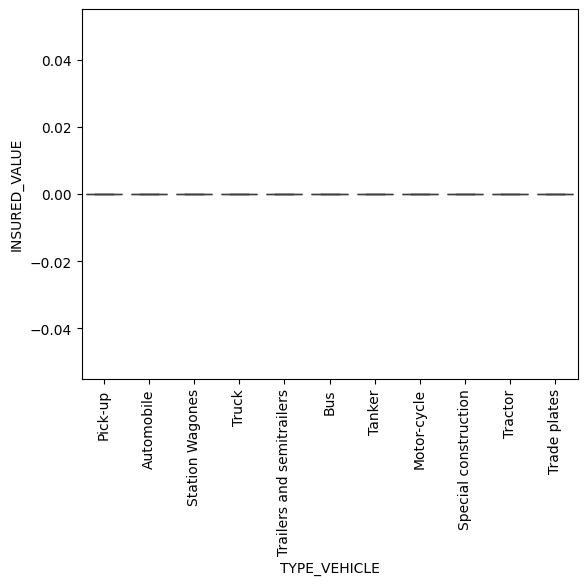

0


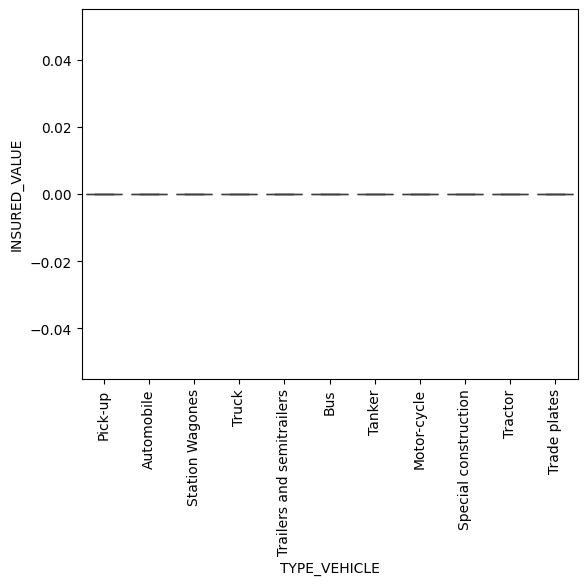

In [8]:
sns.boxplot(data=df, x='TYPE_VEHICLE', y='INSURED_VALUE')
plt.xticks(rotation = 90)
plt.show()

insr_val_quantile = df['INSURED_VALUE'].quantile(0.95)
insr_val_quantile = (100 if df.iloc[0]['INSR_ZERO'] else insr_val_quantile)
filtering_config[insr_key]['INSURED_VALUE'] = insr_val_quantile

print((df['INSURED_VALUE'] >= insr_val_quantile).sum())

df = df[df['INSURED_VALUE'] < insr_val_quantile].reset_index(drop=True)

sns.boxplot(data=df, x='TYPE_VEHICLE', y='INSURED_VALUE')
plt.xticks(rotation = 90)
plt.show()

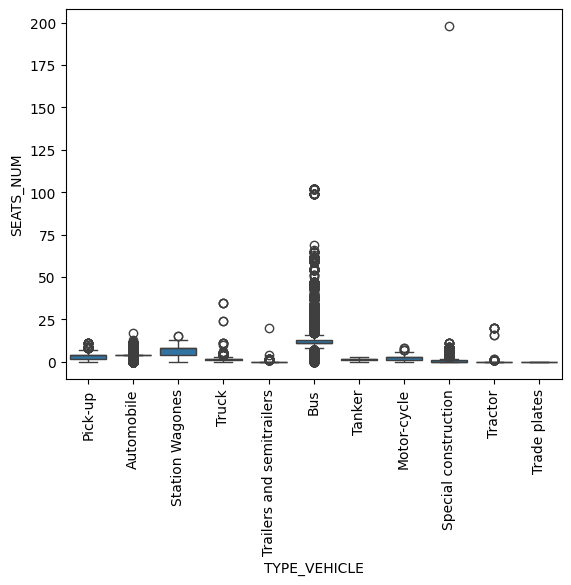

2570


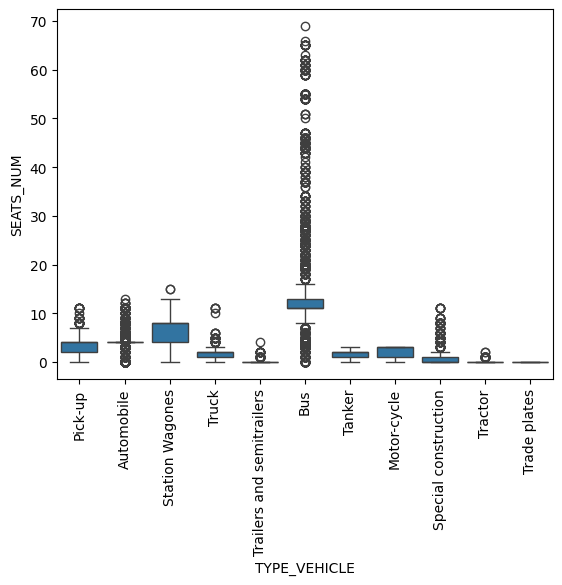

In [9]:
sns.boxplot(data=df, x='TYPE_VEHICLE', y='SEATS_NUM')
plt.xticks(rotation = 90)
plt.show()

limits = [(20, 'Truck'), (80, 'Bus'), (20, 'Pick-up'), (50, 'Station Wagones'), (16, 'Automobile'), (4, 'Motor-cycle'), (10, 'Tanker'),
            (10, 'Trailers and semitrailers'), (20, 'Special construction'), (10, 'Tractor'), (10, 'Trade plates')]

l = False

for (a, b) in limits:
    l = (df['SEATS_NUM'] < a) & (df['TYPE_VEHICLE'] == b) | l

filtering_config[insr_key]['SEATS_NUM'] = limits

print((~l).sum())

df = df[l].reset_index(drop=True)

sns.boxplot(data=df, x='TYPE_VEHICLE', y='SEATS_NUM')
plt.xticks(rotation = 90)
plt.show()

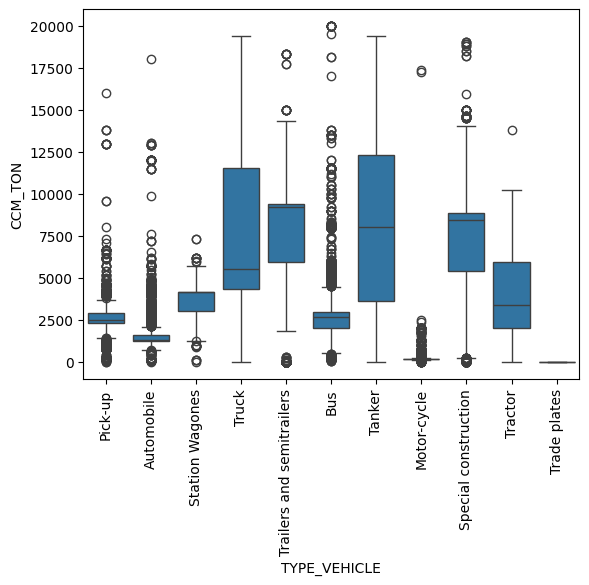

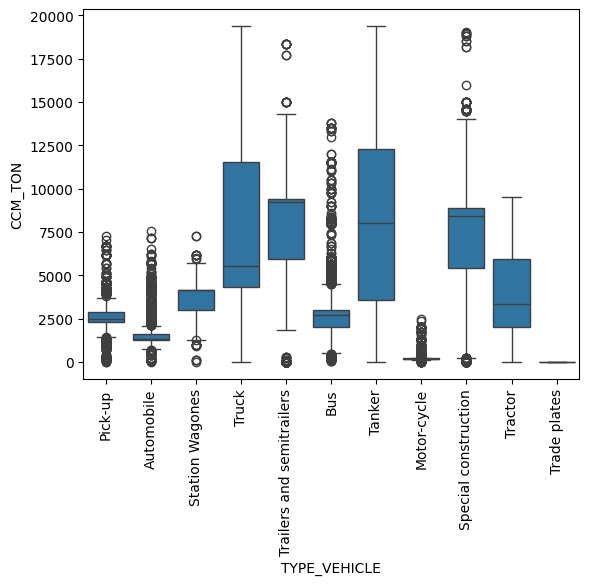

In [10]:
sns.boxplot(data=df, x='TYPE_VEHICLE', y='CCM_TON')
plt.xticks(rotation = 90)
plt.show()

if df.iloc[0]['INSR_ZERO']:
    limits = [(20000, 'Truck'), (15000, 'Bus'), (7500, 'Pick-up'), (10000, 'Station Wagones'), (9000, 'Automobile'), (10000, 'Motor-cycle'), (20000, 'Tanker'),
          (20000, 'Trailers and semitrailers'), (20000, 'Special construction'), (10000, 'Tractor'), (10000, 'Trade plates')]
    l = 0

    for (a, b) in limits:
        l = (df['CCM_TON'] < a) & (df['TYPE_VEHICLE'] == b) | l

    df = df[l].reset_index(drop=True)

else:
    limits = df['CCM_TON'].quantile(0.95)
    print(limits)
    print((df['CCM_TON'] >= limits).sum())
    df = df[df['CCM_TON'] < limits].reset_index(drop=True)

filtering_config[insr_key]['CCM_TON'] = limits

sns.boxplot(data=df, x='TYPE_VEHICLE', y='CCM_TON')
plt.xticks(rotation = 90)
plt.show()

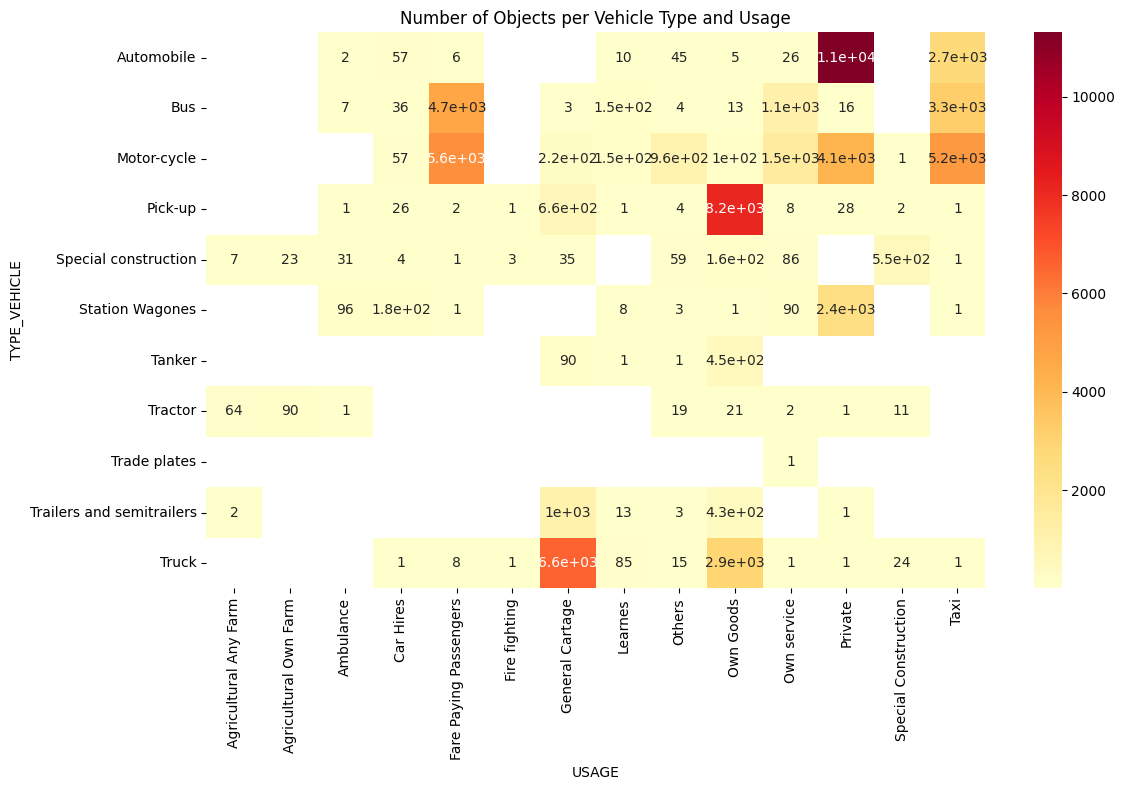

In [11]:
matrix = pd.crosstab(
    df['TYPE_VEHICLE'], 
    df['USAGE'], 
    values=df['OBJECT_ID'], 
    aggfunc='nunique'
)

plt.figure(figsize=(12, 8))
sns.heatmap(matrix, annot=True, cmap='YlOrRd')
plt.title('Number of Objects per Vehicle Type and Usage')
plt.tight_layout()
plt.show()

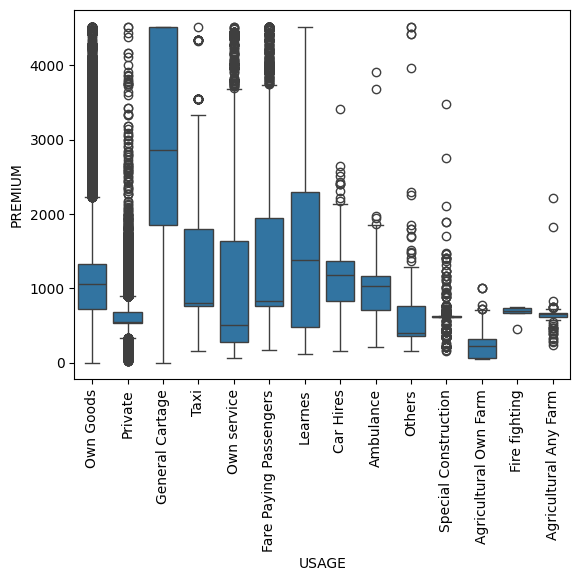

In [12]:
sns.boxplot(data=df, x='USAGE', y='PREMIUM')
plt.xticks(rotation = 90)
plt.show()

In [13]:
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn

def krusk_analysis(column):
    groups = [group['PREMIUM'].values for name, group in df.groupby(column)]
    h_stat, p_value = kruskal(*groups)
    print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
    print(f"Kruskal-Wallis p-value: {p_value:.4e}\n")

    dunn_results = posthoc_dunn(df, val_col='PREMIUM', group_col=column, p_adjust='bonferroni')
    print("Dunn's test p-values (Bonferroni adjusted):")
    print(dunn_results)

    similar_pairs_dunn = []
    for i in range(len(dunn_results.index)):
        for j in range(i+1, len(dunn_results.columns)):
            if dunn_results.iloc[i, j] > 0.05:
                similar_pairs_dunn.append((dunn_results.index[i], dunn_results.columns[j], dunn_results.iloc[i, j]))

    print("\nPairs that can potentially be combined (p > 0.05):")
    for pair in similar_pairs_dunn:
        print(f"{pair[0]} & {pair[1]}: p = {pair[2]:.4f}")
    return similar_pairs_dunn

from scipy.stats import mannwhitneyu

def man_whitn_validation(similar_pairs_dunn, column):
    print("Re-validating combinations with Mann-Whitney:\n")
    for (cat1, cat2, *_) in similar_pairs_dunn:
        group1 = df[df[column] == cat1]['PREMIUM']
        group2 = df[df[column] == cat2]['PREMIUM']
        
        if len(group1) > 0 and len(group2) > 0:
            u_stat, p_val = mannwhitneyu(group1, group2)
            
            n1, n2 = len(group1), len(group2)
            cliff_delta = (2 * u_stat) / (n1 * n2) - 1
            
            if p_val > 0.3:
                print(f"{cat1} & {cat2}: p={p_val:.4f}, effect={cliff_delta:.3f}")

# Объединение категорий в TYPE_VEHICLE

Следующие ячейки запускаются итеративно с накоплением правил в следующей ячейке

In [14]:
if df.iloc[0]['INSR_ZERO']:
    df['TYPE_VEHICLE'] = df['TYPE_VEHICLE'].replace('Trade plates', 'Station Wagones')
    # filtering_config[insr_key]['MIX_TYPE_VEHICLE'] = [('Trade plates', 'Station Wagones')]
else:
    df['TYPE_VEHICLE'] = df['TYPE_VEHICLE'].replace('Trade plates', 'Motor-cycle')
    filtering_config[insr_key]['MIX_TYPE_VEHICLE'] = [('Trade plates', 'Motor-cycle'), ('Tanker', 'Truck')]


In [15]:
similar_pairs_dunn = krusk_analysis('TYPE_VEHICLE')

Kruskal-Wallis H-statistic: 61635.7357
Kruskal-Wallis p-value: 0.0000e+00

Dunn's test p-values (Bonferroni adjusted):
                              Automobile           Bus    Motor-cycle  \
Automobile                  1.000000e+00  0.000000e+00  8.851546e-167   
Bus                         0.000000e+00  1.000000e+00   0.000000e+00   
Motor-cycle                8.851546e-167  0.000000e+00   1.000000e+00   
Pick-up                     0.000000e+00  0.000000e+00   0.000000e+00   
Special construction        4.336338e-01  0.000000e+00   1.871977e-13   
Station Wagones             0.000000e+00  0.000000e+00   0.000000e+00   
Tanker                      0.000000e+00  4.066608e-33   0.000000e+00   
Tractor                     8.057276e-21  0.000000e+00   1.747123e-05   
Trailers and semitrailers   1.676110e-01  0.000000e+00   4.719741e-16   
Truck                       0.000000e+00  4.852767e-60   0.000000e+00   

                                 Pick-up  Special construction  \
Automobile 

In [16]:
man_whitn_validation(similar_pairs_dunn, 'TYPE_VEHICLE')

Re-validating combinations with Mann-Whitney:



# Объединение категорий в USAGE

In [17]:
if df.iloc[0]['INSR_ZERO']:
    df['USAGE'] = df['USAGE'].replace('Fire fighting', 'Own service')
    df['USAGE'] = df['USAGE'].replace('Agricultural Any Farm', 'Own service')
    df['USAGE'] = df['USAGE'].replace('Fare Paying Passengers', 'Learnes')
    # filtering_config[insr_key]['MIX_USAGE'] = [('Fire fighting', 'Own service'), ('Agricultural Any Farm', 'Own service'), ('Fare Paying Passengers', 'Learnes')]
else:
    df['USAGE'] = df['USAGE'].replace('Fire fighting', 'Private')
    filtering_config[insr_key]['MIX_USAGE'] = [('Agricultural Any Farm', 'Own service')]

In [18]:
similar_pairs_dunn = krusk_analysis('USAGE')

Kruskal-Wallis H-statistic: 34398.8392
Kruskal-Wallis p-value: 0.0000e+00

Dunn's test p-values (Bonferroni adjusted):
                       Agricultural Own Farm     Ambulance     Car Hires  \
Agricultural Own Farm           1.000000e+00  3.794402e-52  2.408459e-85   
Ambulance                       3.794402e-52  1.000000e+00  1.000000e+00   
Car Hires                       2.408459e-85  1.000000e+00  1.000000e+00   
General Cartage                2.547514e-267  1.370209e-36  3.673966e-67   
Learnes                        3.830266e-120  1.000000e+00  1.000000e+00   
Others                          8.295359e-17  2.863113e-30  5.522579e-80   
Own Goods                      8.909403e-117  1.000000e+00  1.000000e+00   
Own service                     3.085185e-49  6.532194e-09  1.250398e-31   
Private                         1.064195e-20  1.553100e-31  2.738748e-96   
Special Construction            2.728677e-22  7.231397e-22  4.356366e-57   
Taxi                           2.670983e-116 

In [19]:
man_whitn_validation(similar_pairs_dunn, 'USAGE')

Re-validating combinations with Mann-Whitney:



# Объединение категорий в SEX (не требуется)

In [20]:
similar_pairs_dunn = krusk_analysis('SEX')

Kruskal-Wallis H-statistic: 43.3950
Kruskal-Wallis p-value: 3.7747e-10

Dunn's test p-values (Bonferroni adjusted):
              0         1             2
0  1.000000e+00  0.000001  1.006805e-08
1  1.400469e-06  1.000000  2.219157e-02
2  1.006805e-08  0.022192  1.000000e+00

Pairs that can potentially be combined (p > 0.05):


In [21]:
man_whitn_validation(similar_pairs_dunn, 'SEX')

Re-validating combinations with Mann-Whitney:



# Объединение категорий в INSR_TYPE (не требуется)

In [22]:
similar_pairs_dunn = krusk_analysis('INSR_TYPE')

Kruskal-Wallis H-statistic: 22184.2130
Kruskal-Wallis p-value: 0.0000e+00

Dunn's test p-values (Bonferroni adjusted):
          1201          1202          1204
1201  1.000000  0.000000e+00  8.806154e-04
1202  0.000000  1.000000e+00  1.129351e-53
1204  0.000881  1.129351e-53  1.000000e+00

Pairs that can potentially be combined (p > 0.05):


In [23]:
man_whitn_validation(similar_pairs_dunn, 'INSR_TYPE')

Re-validating combinations with Mann-Whitney:



In [24]:
df.to_csv(f'insr_{'>0' if insr_key == 'ELSE' else '=0'}.csv', index=False)

In [ ]:
# with open('filtering_config.json', 'w') as f:
#     json.dump(filtering_config, f)

: 

: 

# Тест на схожесть результатов

(На конфигах, сгенерированных этим ноутбуком)

In [ ]:
import pandas as pd

df_zero = pd.read_csv('insr_=0.csv').drop(columns=['INSR_ZERO'])
df_else = pd.read_csv('insr_>0.csv').drop(columns=['INSR_ZERO'])

: 

: 

In [ ]:
from data_filtering import InsuranceDataProcessor

idp = InsuranceDataProcessor('configs/filters')

df = pd.read_csv('no_nans.csv')

df1_zero, df1_else, outlier_metrics = idp.filter_outliers(df)

print(outlier_metrics)

{'removed_by_filter': {'INSR_ZERO_PREMIUM': 6211, 'ELSE_PREMIUM': 8885, 'ELSE_INSURED_VALUE': 9068, 'INSR_ZERO_SEATS_NUM': 2570, 'ELSE_SEATS_NUM': 694, 'INSR_ZERO_CCM_TON': 62, 'ELSE_CCM_TON': 8171}, 'zero_insured_records': 111838, 'positive_insured_records': 177682, 'final_zero_records': 102995, 'final_positive_records': 150864}


: 

: 

In [ ]:
df1_else.columns, df_else.columns

(Index(['SEX', 'INSR_TYPE', 'INSURED_VALUE', 'PREMIUM', 'OBJECT_ID',
        'PROD_YEAR', 'SEATS_NUM', 'TYPE_VEHICLE', 'CCM_TON', 'MAKE', 'USAGE',
        'DURATION', 'OLD_MAKE'],
       dtype='str'),
 Index(['SEX', 'INSR_TYPE', 'INSURED_VALUE', 'PREMIUM', 'OBJECT_ID',
        'PROD_YEAR', 'SEATS_NUM', 'TYPE_VEHICLE', 'CCM_TON', 'MAKE', 'USAGE',
        'DURATION', 'OLD_MAKE'],
       dtype='str'))

: 

: 

In [ ]:
len(df_else), len(df1_else)

(150864, 150864)

: 

: 

In [ ]:
assert (df_zero == df1_zero).all().all()
assert (df_else == df1_else).all().all()

: 

: 